In [377]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install kagglehub[pandas-datasets]

In [378]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import pandas as pd

In [379]:
file_path = "2025_june_raw.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nazarantoniuk/it-salary-ukraine-2025",
    file_path,
    pandas_kwargs={"sep": ";"}
)


Using Colab cache for faster access to the 'it-salary-ukraine-2025' dataset.


In [380]:
df.drop(columns=["Submitted at", "Кількість спеціалістів у вашій компанії в Україні", "Де ви зараз живете?", "Всі бонуси (на місяць)", "Вкажіть вашу основну спеціалізацію", "За яким напрямом ви навчалися / навчаєтеся у виші?", "У якій сфері проєкт, в якому ви зараз працюєте?"], inplace=True)

df = df.dropna(axis="index", how="all")
df = df.dropna(axis="columns", how="all")

condition = df['Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?'] == 'Ні, не використовую'
df.loc[condition, 'Основна мова програмування'] = 'Не використовую'

condition = df['Основна мова програмування'] != 'Не використовую'
df.loc[condition, 'Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?'] = 'Так, використовую'

condition = df["Ваша основна зайнятість в ІТ зараз..."] == "Я фрилансер(-ка) в ІТ"
df.loc[condition, 'Основний напрям роботи компанії, в якій працюєте'] = 'Фріланс'

df = df.dropna(subset=["ЗАРПЛАТА / СУМАРНИЙ ДОХІД в IT у $$$ за місяць, лише ставка \nЧИСТИМИ - після сплати податків"])

has_nulls = df.isna().any().any()

if has_nulls:
  print("❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌❌ Є нули")
else:
  print("✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️Нема нулів")


✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️✔️Нема нулів


In [381]:
col_name = 'Основна мова програмування'

counts = df[col_name].value_counts()
popular_roles = counts[counts >= 25].index
df.loc[~df[col_name].isin(popular_roles), col_name] = 'Інше'

col_name = 'Почніть вводити і оберіть вашу ОСНОВНУ посаду зі списку'

counts = df[col_name].value_counts()
popular_roles = counts[counts >= 30].index
df.loc[~df[col_name].isin(popular_roles), col_name] = 'Інше'


In [382]:
df = df.rename(columns={
    "Ваша основна зайнятість в ІТ зараз...": "Employment",
    "ЗАРПЛАТА / СУМАРНИЙ ДОХІД в IT у $$$ за місяць, лише ставка \nЧИСТИМИ - після сплати податків": "Salary",
    "Тайтл": "Title",
    "Категорія": "Category",
    "Почніть вводити і оберіть вашу ОСНОВНУ посаду зі списку": "Position",
    "Чи використовуєте ви у своїй роботі мови програмування (одну чи декілька)?": "Uses_Code",
    "Основна мова програмування": "Language",
    "Основний напрям роботи компанії, в якій працюєте": "Company_Type",
    "Загальний стаж роботи за нинішньою ІТ-спеціальністю": "Experience",
    "Знання англійської мови": "English",
    "Ваш вік": "Age"
})

In [383]:
df.head()

,Employment,Salary,Title,Category,Position,Uses_Code,Language,Company_Type,Experience,English,Age
0,Втратив(-ла) роботу / звільнився(-лася) і шука...,2000.0,Middle,Marketing,Marketing Manager,"Ні, не використовую",Не використовую,Продуктова,4.00,Upper-Intermediate,21.0
1,Працюю в IT-компанії / ІТ-департаменті,3000.0,Senior,SE,"Software Engineer / Developer (frontend, backe...","Так, використовую",1С,Продуктова,8.00,Pre-Intermediate,33.0
2,Працюю в IT-компанії / ІТ-департаменті,282.0,Junior,SE,"Software Engineer / Developer (frontend, backe...","Так, використовую",C# / .NET,Сервісна (аутсорсингова),0.25,Pre-Intermediate,32.0
3,Працюю в IT-компанії / ІТ-департаменті,2700.0,Middle,QA,Manual QA,"Так, використовую",Python,"ІТ-відділ в НЕ ІТ-компанії (банк, телеком, рит...",4.00,Upper-Intermediate,26.0
4,Працюю в IT-компанії / ІТ-департаменті,2500.0,Middle,SE,"Software Engineer / Developer (frontend, backe...","Так, використовую",C++,Стартап,4.00,Intermediate,24.0


In [384]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11685 entries, 0 to 11685
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Employment    11685 non-null  object 
 1   Salary        11685 non-null  float64
 2   Title         11685 non-null  object 
 3   Category      11685 non-null  object 
 4   Position      11685 non-null  object 
 5   Uses_Code     11685 non-null  object 
 6   Language      11685 non-null  object 
 7   Company_Type  11685 non-null  object 
 8   Experience    11685 non-null  float64
 9   English       11685 non-null  object 
 10  Age           11685 non-null  float64
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [385]:
for col in df.columns:
  print(col)
  print(df[col].unique().shape[0])

Employment
6
Salary
1062
Title
13
Category
36
Position
37
Uses_Code
2
Language
24
Company_Type
8
Experience
20
English
6
Age
51


In [386]:
salary_corr = df.corr(numeric_only=True)['Salary'].sort_values(ascending=False)

print(salary_corr)

Salary        1.000000
Experience    0.474887
Age           0.288797
Name: Salary, dtype: float64


<Axes: >

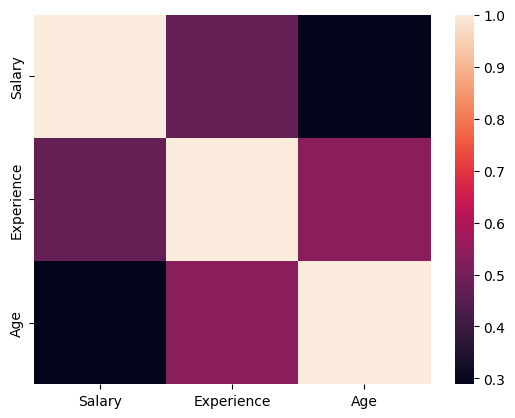

In [387]:
sns.heatmap(df.corr(numeric_only=True))

In [388]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [389]:
print(df_encoded.dtypes.value_counts())

bool       124
float64      3
Name: count, dtype: int64


In [391]:
print(df.select_dtypes(include=['float64']).describe())

             Salary    Experience           Age
count  11685.000000  11685.000000  11685.000000
mean    3231.505930      5.472058     31.042833
std     2319.571734      4.056731      6.739319
min        0.000000      0.100000     17.000000
25%     1500.000000      3.000000     26.000000
50%     2700.000000      5.000000     30.000000
75%     4430.000000      7.000000     35.000000
max    30000.000000     20.000000     69.000000


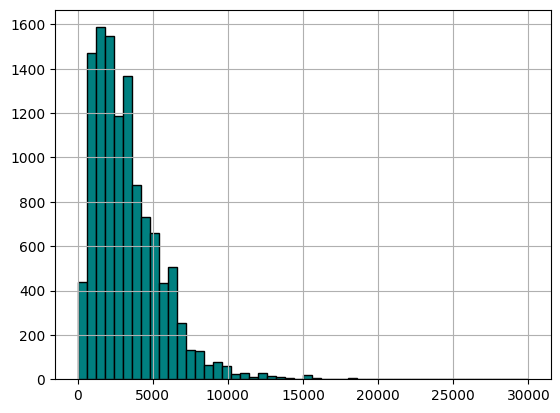

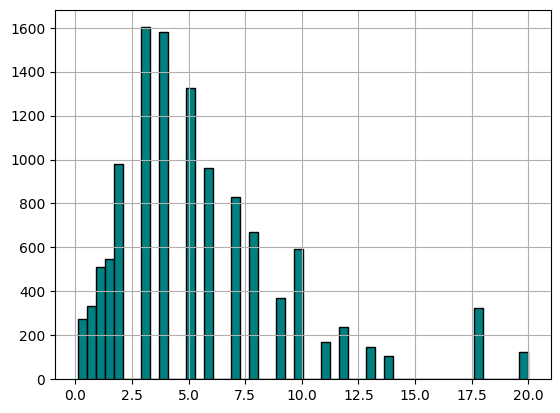

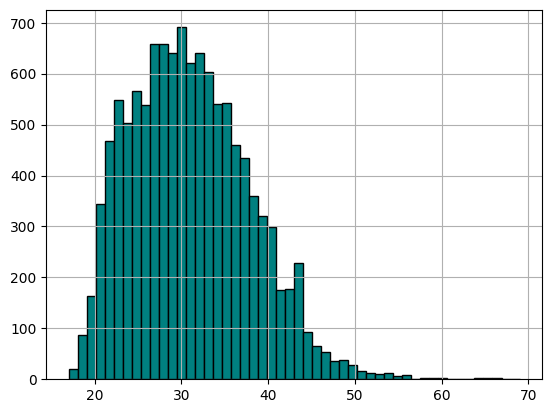

In [398]:
df['Salary'].hist(bins=50, color='teal', edgecolor='black')
plt.show()
df['Experience'].hist(bins=50, color='teal', edgecolor='black')
plt.show()
df['Age'].hist(bins=50, color='teal', edgecolor='black')
plt.show()
